# 🔗 Intelligent Supply Chain Optimization System
## Notebook 07 — Inventory Optimization

**Project:** Intelligent Supply Chain Optimization System  
**Phase:** The Action — Inventory Policy Engine  
**Input:** `hybrid_predictions.csv` (output from Notebook 06)  
**Objective:** Use the Hybrid Model forecast to compute Dynamic Reorder Points and Economic Order Quantities, then simulate and evaluate the resulting inventory policy.

---

### 📋 What This Notebook Does
1. Load hybrid predictions + original dataset
2. Compute demand statistics per SKU (mean, std, lead time)
3. Calculate Dynamic Reorder Point (ROP)
4. Calculate Economic Order Quantity (EOQ)
5. Calculate Safety Stock
6. Simulate inventory policy: Hybrid Forecast vs Baseline Forecast vs Original Policy
7. Evaluate: Stockout events, Overstock costs, Total inventory cost
8. Visualize inventory trajectories per SKU
9. Business value summary (cost savings)
10. Save final optimization results

---

## 📦 Section 1: Imports & Load Data

In [1]:
# ─────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS & LOAD
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import json

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight']  = 'bold'
sns.set_palette('muted')

# ── Load hybrid predictions ──
hybrid = pd.read_csv('hybrid_predictions.csv', parse_dates=['Date'])

# ── Load original validated dataset (for cost, lead time, inventory info) ──
raw = pd.read_csv('supply_chain_validated.csv', parse_dates=['Date'])

# ── Load hybrid metrics ──
with open('hybrid_metrics.json') as f:
    hybrid_metrics = json.load(f)

print(f'✅ Hybrid predictions : {hybrid.shape}')
print(f'✅ Raw dataset        : {raw.shape}')
print(f'   Date range         : {hybrid["Date"].min().date()} → {hybrid["Date"].max().date()}')
print(f'   Unique SKUs        : {hybrid["SKU_ID"].nunique()}')
print(f'\n   Best hybrid strategy : {hybrid_metrics.get("best_strategy", "Hybrid Weighted")}')

✅ Hybrid predictions : (6000, 12)
✅ Raw dataset        : (91250, 15)
   Date range         : 2024-12-07 → 2024-12-30
   Unique SKUs        : 50

   Best hybrid strategy : XGBoost


---
## 📊 Section 2: Compute Demand Statistics Per SKU

In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 2: DEMAND STATISTICS PER SKU × WAREHOUSE
# ─────────────────────────────────────────────────────────────
# We compute statistics from the TRAINING period only
# (i.e. all data BEFORE the test set) to avoid leakage
# into the policy parameters.
# ─────────────────────────────────────────────────────────────

GROUP_KEYS = ['SKU_ID', 'Warehouse_ID']

# Use training period from raw dataset
unique_dates  = sorted(raw['Date'].unique())
train_cutoff  = unique_dates[int(len(unique_dates) * 0.70)]
train_raw     = raw[raw['Date'] <= train_cutoff]

sku_stats = train_raw.groupby(GROUP_KEYS).agg(
    Avg_Daily_Demand   = ('Units_Sold',              'mean'),
    Std_Daily_Demand   = ('Units_Sold',              'std'),
    Avg_Lead_Time      = ('Supplier_Lead_Time_Days', 'mean'),
    Std_Lead_Time      = ('Supplier_Lead_Time_Days', 'std'),
    Avg_Unit_Cost      = ('Unit_Cost',               'mean'),
    Avg_Unit_Price     = ('Unit_Price',              'mean'),
    Annual_Demand      = ('Units_Sold',              'sum'),
    Holding_Cost_Rate  = ('Unit_Cost',               'mean'),  # used as proxy
).reset_index()

# Fill NaN std with 0 (single-record groups)
sku_stats['Std_Daily_Demand'] = sku_stats['Std_Daily_Demand'].fillna(0)
sku_stats['Std_Lead_Time']    = sku_stats['Std_Lead_Time'].fillna(0)

# Annualise demand (training period → scale to 365 days)
train_days = (pd.Timestamp(train_cutoff) - pd.Timestamp(unique_dates[0])).days + 1
sku_stats['Annual_Demand'] = (sku_stats['Annual_Demand'] / train_days * 365).round(1)

print(f'✅ Demand statistics computed for {len(sku_stats)} SKU×Warehouse combinations')
print(f'   Training period: {pd.Timestamp(unique_dates[0]).date()} → {pd.Timestamp(train_cutoff).date()} ({train_days} days)')
# print(f'   Training period: {unique_dates[0].astype("datetime64[D]")} → {train_cutoff.astype("datetime64[D]")} ({train_days} days)')
print()
print(sku_stats.describe().round(3))

✅ Demand statistics computed for 250 SKU×Warehouse combinations
   Training period: 2024-01-01 → 2024-09-12 (256 days)

       Avg_Daily_Demand  Std_Daily_Demand  Avg_Lead_Time  Std_Lead_Time  \
count          250.0000          250.0000       250.0000       250.0000   
mean            23.0600            8.4300         7.9840         0.0000   
std              0.3240            0.3340         3.9160         0.0000   
min             22.2580            7.6100         2.0000         0.0000   
25%             22.8670            8.1830         4.0000         0.0000   
50%             23.0510            8.3990         8.0000         0.0000   
75%             23.2660            8.6720        11.0000         0.0000   
max             23.9840            9.2930        14.0000         0.0000   

       Avg_Unit_Cost  Avg_Unit_Price  Annual_Demand  Holding_Cost_Rate  
count       250.0000        250.0000       250.0000           250.0000  
mean         12.2030         18.2620      8416.9470       

---
## 🔒 Section 3: Safety Stock

In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 3: SAFETY STOCK
# ─────────────────────────────────────────────────────────────
# Safety Stock formula:
#   SS = Z × sqrt(L × σ_d² + d² × σ_L²)
#
# Where:
#   Z    = service level Z-score (95% → 1.645)
#   L    = average lead time (days)
#   σ_d  = std of daily demand
#   d    = average daily demand
#   σ_L  = std of lead time
# ─────────────────────────────────────────────────────────────

SERVICE_LEVEL = 0.95          # 95% service level
Z_SCORE       = 1.645         # Z-score for 95%

sku_stats['Safety_Stock'] = (
    Z_SCORE * np.sqrt(
        sku_stats['Avg_Lead_Time']  * sku_stats['Std_Daily_Demand']**2 +
        sku_stats['Avg_Daily_Demand']**2 * sku_stats['Std_Lead_Time']**2
    )
).round(2)

# Also compute a baseline safety stock (using only demand std, simpler formula)
sku_stats['Safety_Stock_Baseline'] = (
    Z_SCORE * sku_stats['Std_Daily_Demand'] * np.sqrt(sku_stats['Avg_Lead_Time'])
).round(2)

print(f'✅ Safety Stock computed (Service Level: {SERVICE_LEVEL*100:.0f}%, Z={Z_SCORE})')
print()
print('── Safety Stock Summary ──')
print(f'  Mean Safety Stock        : {sku_stats["Safety_Stock"].mean():.2f} units')
print(f'  Min  Safety Stock        : {sku_stats["Safety_Stock"].min():.2f} units')
print(f'  Max  Safety Stock        : {sku_stats["Safety_Stock"].max():.2f} units')
print(f'  Mean SS Baseline (simple): {sku_stats["Safety_Stock_Baseline"].mean():.2f} units')

✅ Safety Stock computed (Service Level: 95%, Z=1.645)

── Safety Stock Summary ──
  Mean Safety Stock        : 37.84 units
  Min  Safety Stock        : 18.42 units
  Max  Safety Stock        : 56.55 units
  Mean SS Baseline (simple): 37.84 units


---
## 📍 Section 4: Dynamic Reorder Point (ROP)

In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 4: DYNAMIC REORDER POINT
# ─────────────────────────────────────────────────────────────
# ROP formula:
#   ROP = (Average Daily Demand × Average Lead Time) + Safety Stock
#
# We compute THREE versions:
#   1. ROP_Original  — from the dataset's own Reorder_Point column
#   2. ROP_Baseline  — using Demand_Forecast mean as demand estimate
#   3. ROP_Hybrid    — using our Hybrid Model forecast mean
# ─────────────────────────────────────────────────────────────

# ── Hybrid forecast demand stats (from test period) ──
hybrid_stats = hybrid.groupby(GROUP_KEYS).agg(
    Hybrid_Avg_Demand   = ('Hybrid_Pred',      'mean'),
    Hybrid_Std_Demand   = ('Hybrid_Pred',      'std'),
    Baseline_Avg_Demand = ('Demand_Forecast',  'mean'),
).reset_index()
hybrid_stats['Hybrid_Std_Demand'] = hybrid_stats['Hybrid_Std_Demand'].fillna(0)

# Merge into sku_stats
sku_policy = sku_stats.merge(hybrid_stats, on=GROUP_KEYS, how='left')

# ── Original ROP (from raw dataset) ──
original_rop = raw.groupby(GROUP_KEYS)['Reorder_Point'].mean().reset_index()
original_rop.columns = GROUP_KEYS + ['ROP_Original']
sku_policy = sku_policy.merge(original_rop, on=GROUP_KEYS, how='left')

# ── ROP using Baseline forecast ──
sku_policy['ROP_Baseline'] = (
    sku_policy['Baseline_Avg_Demand'] * sku_policy['Avg_Lead_Time'] +
    sku_policy['Safety_Stock_Baseline']
).round(2)

# ── ROP using Hybrid forecast (our model) ──
sku_policy['ROP_Hybrid'] = (
    sku_policy['Hybrid_Avg_Demand'] * sku_policy['Avg_Lead_Time'] +
    sku_policy['Safety_Stock']
).round(2)

print('✅ Reorder Points computed (3 versions)')
print()
print('── ROP Comparison (mean across all SKUs) ──')
print(f'  ROP Original (dataset)  : {sku_policy["ROP_Original"].mean():.2f}')
print(f'  ROP Baseline forecast   : {sku_policy["ROP_Baseline"].mean():.2f}')
print(f'  ROP Hybrid forecast     : {sku_policy["ROP_Hybrid"].mean():.2f}')
print()
print(sku_policy[GROUP_KEYS + ['ROP_Original','ROP_Baseline','ROP_Hybrid','Safety_Stock']].head(10))

✅ Reorder Points computed (3 versions)

── ROP Comparison (mean across all SKUs) ──
  ROP Original (dataset)  : 300.07
  ROP Baseline forecast   : 182.84
  ROP Hybrid forecast     : 182.91

   SKU_ID Warehouse_ID  ROP_Original  ROP_Baseline  ROP_Hybrid  Safety_Stock
0   SKU_1         WH_1      379.0000      294.9600    287.1000       52.1900
1   SKU_1         WH_2      322.0000      169.4100    180.4300       36.9000
2   SKU_1         WH_3      314.0000      136.3800    143.7900       32.6800
3   SKU_1         WH_4      333.0000      217.6700    215.6100       40.1600
4   SKU_1         WH_5      366.0000      100.7900    101.4600       27.4700
5  SKU_10         WH_1      361.0000      284.5900    266.3300       51.4900
6  SKU_10         WH_2      310.0000      214.1500    221.9800       42.3100
7  SKU_10         WH_3      218.0000      131.8100    132.3100       30.9000
8  SKU_10         WH_4      328.0000      301.1000    304.6000       51.5700
9  SKU_10         WH_5      246.0000    

---
## 📦 Section 5: Economic Order Quantity (EOQ)

In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 5: ECONOMIC ORDER QUANTITY (EOQ)
# ─────────────────────────────────────────────────────────────
# EOQ formula (Wilson formula):
#   EOQ = sqrt( (2 × D × S) / H )
#
# Where:
#   D = Annual demand (units/year)
#   S = Ordering cost per order (fixed — we use a standard $50)
#   H = Holding cost per unit per year (= Unit_Cost × holding rate)
#
# Holding rate: typically 20-30% of unit cost per year.
# We use 25% as the industry standard.
# ─────────────────────────────────────────────────────────────

ORDERING_COST   = 50.0    # $ per order placed
HOLDING_RATE    = 0.25    # 25% of unit cost per year

sku_policy['Holding_Cost_Per_Unit'] = (
    sku_policy['Avg_Unit_Cost'] * HOLDING_RATE
).round(4)

# ── EOQ using Original demand ──
sku_policy['EOQ_Original'] = np.sqrt(
    (2 * sku_policy['Annual_Demand'] * ORDERING_COST) /
    sku_policy['Holding_Cost_Per_Unit'].replace(0, 1e-6)
).round(0)

# ── EOQ using Hybrid forecast demand ──
hybrid_annual = hybrid.groupby(GROUP_KEYS)['Hybrid_Pred'].sum().reset_index()
hybrid_annual.columns = GROUP_KEYS + ['Hybrid_Annual_Demand']
# Scale to 365 days
test_days = hybrid.groupby(GROUP_KEYS)['Date'].nunique().reset_index()
test_days.columns = GROUP_KEYS + ['Test_Days']
hybrid_annual = hybrid_annual.merge(test_days, on=GROUP_KEYS)
hybrid_annual['Hybrid_Annual_Demand'] = (
    hybrid_annual['Hybrid_Annual_Demand'] / hybrid_annual['Test_Days'] * 365
).round(1)

sku_policy = sku_policy.merge(hybrid_annual[GROUP_KEYS + ['Hybrid_Annual_Demand']], on=GROUP_KEYS, how='left')

sku_policy['EOQ_Hybrid'] = np.sqrt(
    (2 * sku_policy['Hybrid_Annual_Demand'] * ORDERING_COST) /
    sku_policy['Holding_Cost_Per_Unit'].replace(0, 1e-6)
).round(0)

# EOQ cannot be 0
sku_policy['EOQ_Hybrid']   = sku_policy['EOQ_Hybrid'].clip(lower=1)
sku_policy['EOQ_Original'] = sku_policy['EOQ_Original'].clip(lower=1)

print(f'✅ EOQ computed (Ordering Cost=${ORDERING_COST}, Holding Rate={HOLDING_RATE*100:.0f}%)')
print()
print('── EOQ Comparison ──')
print(f'  EOQ Original (history-based) : {sku_policy["EOQ_Original"].mean():.1f} units/order')
print(f'  EOQ Hybrid   (forecast-based): {sku_policy["EOQ_Hybrid"].mean():.1f} units/order')
print()
print(sku_policy[GROUP_KEYS + ['Annual_Demand','Hybrid_Annual_Demand','EOQ_Original','EOQ_Hybrid']].head(10))

✅ EOQ computed (Ordering Cost=$50.0, Holding Rate=25%)

── EOQ Comparison ──
  EOQ Original (history-based) : 558.2 units/order
  EOQ Hybrid   (forecast-based): 494.5 units/order

   SKU_ID Warehouse_ID  Annual_Demand  Hybrid_Annual_Demand  EOQ_Original  \
0   SKU_1         WH_1      8534.7000             6124.4000      495.0000   
1   SKU_1         WH_2      8415.0000             6548.6000      542.0000   
2   SKU_1         WH_3      8551.8000             6758.9000      751.0000   
3   SKU_1         WH_4      8521.9000             7115.4000      701.0000   
4   SKU_1         WH_5      8539.0000             6751.6000      419.0000   
5  SKU_10         WH_1      8407.8000             6032.0000      515.0000   
6  SKU_10         WH_2      8403.6000             6557.8000      493.0000   
7  SKU_10         WH_3      8338.0000             7403.2000      494.0000   
8  SKU_10         WH_4      8474.8000             6596.8000      422.0000   
9  SKU_10         WH_5      8454.9000             

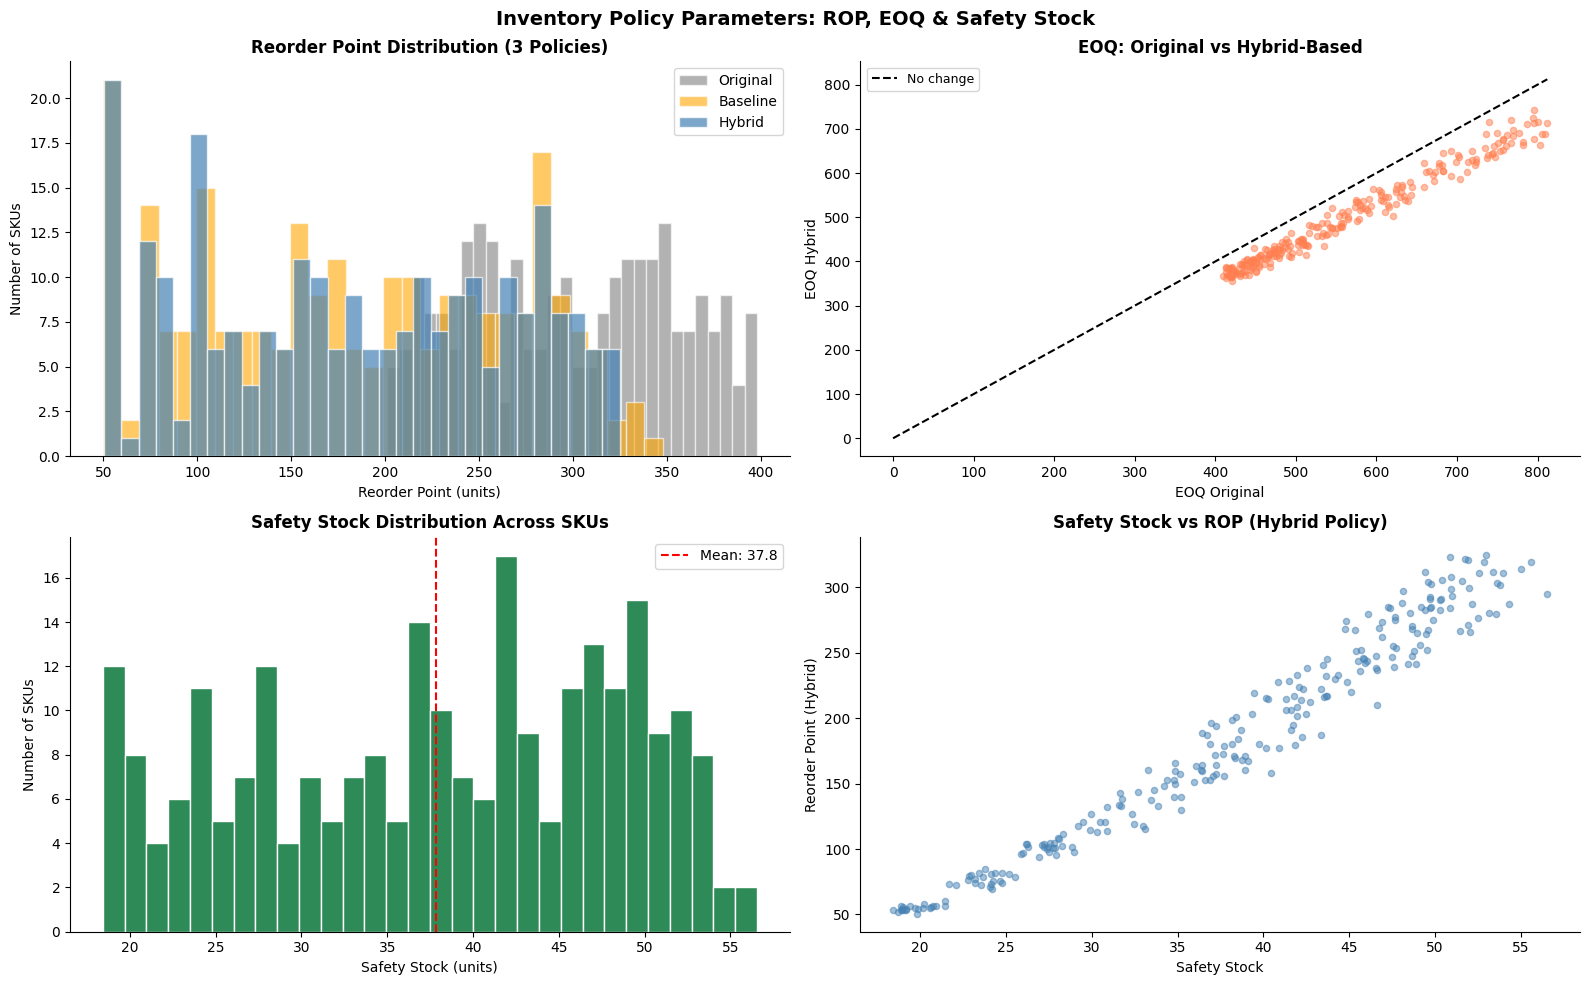

In [6]:
# ── Visualize ROP and EOQ distributions ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ROP comparison
axes[0,0].hist(sku_policy['ROP_Original'], bins=30, alpha=0.6,
               color='grey',      label='Original',  edgecolor='white')
axes[0,0].hist(sku_policy['ROP_Baseline'], bins=30, alpha=0.6,
               color='orange',    label='Baseline',  edgecolor='white')
axes[0,0].hist(sku_policy['ROP_Hybrid'],   bins=30, alpha=0.7,
               color='steelblue', label='Hybrid',    edgecolor='white')
axes[0,0].set_title('Reorder Point Distribution (3 Policies)')
axes[0,0].set_xlabel('Reorder Point (units)')
axes[0,0].set_ylabel('Number of SKUs')
axes[0,0].legend()

# EOQ comparison
axes[0,1].scatter(sku_policy['EOQ_Original'], sku_policy['EOQ_Hybrid'],
                  alpha=0.5, color='coral', s=20)
lim = [0, max(sku_policy['EOQ_Original'].max(), sku_policy['EOQ_Hybrid'].max())]
axes[0,1].plot(lim, lim, 'k--', linewidth=1.5, label='No change')
axes[0,1].set_title('EOQ: Original vs Hybrid-Based')
axes[0,1].set_xlabel('EOQ Original')
axes[0,1].set_ylabel('EOQ Hybrid')
axes[0,1].legend(fontsize=9)

# Safety Stock distribution
axes[1,0].hist(sku_policy['Safety_Stock'], bins=30, color='seagreen', edgecolor='white')
axes[1,0].axvline(sku_policy['Safety_Stock'].mean(), color='red', linestyle='--',
                  label=f'Mean: {sku_policy["Safety_Stock"].mean():.1f}')
axes[1,0].set_title('Safety Stock Distribution Across SKUs')
axes[1,0].set_xlabel('Safety Stock (units)')
axes[1,0].set_ylabel('Number of SKUs')
axes[1,0].legend()

# ROP vs Safety Stock scatter
axes[1,1].scatter(sku_policy['Safety_Stock'], sku_policy['ROP_Hybrid'],
                  alpha=0.5, color='steelblue', s=20)
axes[1,1].set_title('Safety Stock vs ROP (Hybrid Policy)')
axes[1,1].set_xlabel('Safety Stock')
axes[1,1].set_ylabel('Reorder Point (Hybrid)')

plt.suptitle('Inventory Policy Parameters: ROP, EOQ & Safety Stock', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔄 Section 6: Inventory Policy Simulation

In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 6: INVENTORY SIMULATION
# ─────────────────────────────────────────────────────────────
# We simulate inventory day-by-day over the test period
# under 3 policies:
#   1. Original  — use dataset's Reorder_Point & Order_Quantity
#   2. Baseline  — use ROP_Baseline and EOQ_Original
#   3. Hybrid    — use ROP_Hybrid and EOQ_Hybrid
#
# Simulation logic:
#   - Start with initial inventory from dataset
#   - Each day: subtract actual Units_Sold
#   - If inventory ≤ ROP: place an order of size EOQ
#   - Order arrives after Lead_Time days
#   - Track: stockouts, ending inventory, order events
# ─────────────────────────────────────────────────────────────

def simulate_inventory(group_df, rop, eoq, lead_time, initial_inv=None):
    """
    Simulate (s, Q) inventory policy for one SKU×Warehouse.
    Returns daily record of inventory level, stockouts, orders.
    """
    group_df  = group_df.sort_values('Date').reset_index(drop=True)
    n         = len(group_df)
    inv       = initial_inv if initial_inv is not None else group_df['Inventory_Level'].iloc[0]
    inv       = max(inv, eoq)   # ensure we start with at least one EOQ

    inventory  = np.zeros(n)
    stockouts  = np.zeros(n, dtype=int)
    orders     = np.zeros(n)    # order quantity placed each day
    arrivals   = {}             # {day_index: quantity}

    for i in range(n):
        # Receive any pending orders arriving today
        inv += arrivals.pop(i, 0)

        # Fulfil demand
        demand = group_df['Units_Sold'].iloc[i]
        if demand > inv:
            stockouts[i] = 1
            inv = 0
        else:
            inv -= demand

        inventory[i] = inv

        # Check reorder trigger
        if inv <= rop:
            arrival_day = i + int(round(lead_time))
            if arrival_day < n:
                arrivals[arrival_day] = arrivals.get(arrival_day, 0) + eoq
            orders[i] = eoq

    return pd.DataFrame({
        'Date'       : group_df['Date'].values,
        'Inventory'  : inventory,
        'Stockout'   : stockouts,
        'Order_Qty'  : orders,
        'Demand'     : group_df['Units_Sold'].values
    })


print('✅ Simulation function defined.')
print('   Running simulation for all SKU×Warehouse combinations...')

✅ Simulation function defined.
   Running simulation for all SKU×Warehouse combinations...


In [8]:
# ── Run simulation for all 3 policies ──
test_raw = raw[raw['Date'] > pd.Timestamp(train_cutoff)].copy()

sim_results = []

for (sku, wh), grp in test_raw.groupby(GROUP_KEYS):
    key = (sku, wh)

    # Get policy parameters
    policy_row = sku_policy[
        (sku_policy['SKU_ID'] == sku) & (sku_policy['Warehouse_ID'] == wh)
    ]
    if policy_row.empty:
        continue
    p = policy_row.iloc[0]

    lead_time   = p['Avg_Lead_Time']
    rop_orig    = p['ROP_Original']
    rop_base    = p['ROP_Baseline']
    rop_hybrid  = p['ROP_Hybrid']
    eoq_orig    = p['EOQ_Original']
    eoq_hybrid  = p['EOQ_Hybrid']
    unit_cost   = p['Avg_Unit_Cost']
    unit_price  = p['Avg_Unit_Price']
    init_inv    = grp['Inventory_Level'].iloc[0]

    # Policy 1: Original
    sim_orig = simulate_inventory(grp, rop_orig, eoq_orig, lead_time, init_inv)
    # Policy 2: Baseline
    sim_base = simulate_inventory(grp, rop_base, eoq_orig, lead_time, init_inv)
    # Policy 3: Hybrid
    sim_hyb  = simulate_inventory(grp, rop_hybrid, eoq_hybrid, lead_time, init_inv)

    holding_rate_daily = (unit_cost * HOLDING_RATE) / 365

    for policy_name, sim_df in [('Original', sim_orig),
                                  ('Baseline', sim_base),
                                  ('Hybrid',   sim_hyb)]:
        stockout_days   = sim_df['Stockout'].sum()
        avg_inventory   = sim_df['Inventory'].mean()
        total_orders    = (sim_df['Order_Qty'] > 0).sum()
        holding_cost    = avg_inventory * holding_rate_daily * len(sim_df)
        ordering_cost   = total_orders  * ORDERING_COST
        stockout_cost   = stockout_days * p['Avg_Daily_Demand'] * (unit_price - unit_cost)
        total_cost      = holding_cost + ordering_cost + stockout_cost

        sim_results.append({
            'SKU_ID'        : sku,
            'Warehouse_ID'  : wh,
            'Policy'        : policy_name,
            'Stockout_Days' : int(stockout_days),
            'Avg_Inventory' : round(avg_inventory, 2),
            'Total_Orders'  : int(total_orders),
            'Holding_Cost'  : round(holding_cost, 2),
            'Ordering_Cost' : round(ordering_cost, 2),
            'Stockout_Cost' : round(stockout_cost, 2),
            'Total_Cost'    : round(total_cost, 2)
        })

sim_df_all = pd.DataFrame(sim_results)
print(f'✅ Simulation complete: {len(sim_df_all):,} records ({len(sim_df_all)//3} SKU×WH × 3 policies)')

✅ Simulation complete: 750 records (250 SKU×WH × 3 policies)


---
## 📏 Section 7: Policy Evaluation & Cost Comparison

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 7: POLICY EVALUATION
# ─────────────────────────────────────────────────────────────

policy_summary = sim_df_all.groupby('Policy').agg(
    Total_Stockout_Days  = ('Stockout_Days',  'sum'),
    Avg_Stockout_Rate    = ('Stockout_Days',  'mean'),
    Avg_Inventory_Level  = ('Avg_Inventory',  'mean'),
    Total_Orders_Placed  = ('Total_Orders',   'sum'),
    Total_Holding_Cost   = ('Holding_Cost',   'sum'),
    Total_Ordering_Cost  = ('Ordering_Cost',  'sum'),
    Total_Stockout_Cost  = ('Stockout_Cost',  'sum'),
    Total_Cost           = ('Total_Cost',     'sum')
).round(2)

policy_summary = policy_summary.reindex(['Original', 'Baseline', 'Hybrid'])

print('=' * 75)
print('  INVENTORY POLICY EVALUATION')
print('=' * 75)
print(policy_summary.to_string())
print()

# Savings vs Original
orig_cost   = policy_summary.loc['Original', 'Total_Cost']
hyb_cost    = policy_summary.loc['Hybrid',   'Total_Cost']
base_cost   = policy_summary.loc['Baseline', 'Total_Cost']
cost_saving = orig_cost - hyb_cost
pct_saving  = cost_saving / orig_cost * 100 if orig_cost != 0 else 0

orig_so   = policy_summary.loc['Original', 'Total_Stockout_Days']
hyb_so    = policy_summary.loc['Hybrid',   'Total_Stockout_Days']
so_reduction = (orig_so - hyb_so) / orig_so * 100 if orig_so != 0 else 0

print('── Business Value of Hybrid Policy ──')
print(f'  💰 Total Cost Saving vs Original : ${cost_saving:,.2f}  ({pct_saving:+.1f}%)')
print(f'  📉 Stockout Days Reduction       : {orig_so - hyb_so} days  ({so_reduction:+.1f}%)')
print(f'  📦 Avg Inventory Change          : {policy_summary.loc["Hybrid","Avg_Inventory_Level"] - policy_summary.loc["Original","Avg_Inventory_Level"]:+.1f} units')

  INVENTORY POLICY EVALUATION
          Total_Stockout_Days  Avg_Stockout_Rate  Avg_Inventory_Level  Total_Orders_Placed  Total_Holding_Cost  Total_Ordering_Cost  Total_Stockout_Cost  Total_Cost
Policy                                                                                                                                                              
Original                    0             0.0000            2600.6900                 2029         574676.1500          101450.0000               0.0000 676126.1500
Baseline                    0             0.0000            2289.6700                 2008         510108.8700          100400.0000               0.0000 610508.8700
Hybrid                      0             0.0000            2140.7000                 2014         470979.7500          100700.0000               0.0000 571679.7500

── Business Value of Hybrid Policy ──
  💰 Total Cost Saving vs Original : $104,446.40  (+15.4%)
  📉 Stockout Days Reduction       : 0 days  (+0.

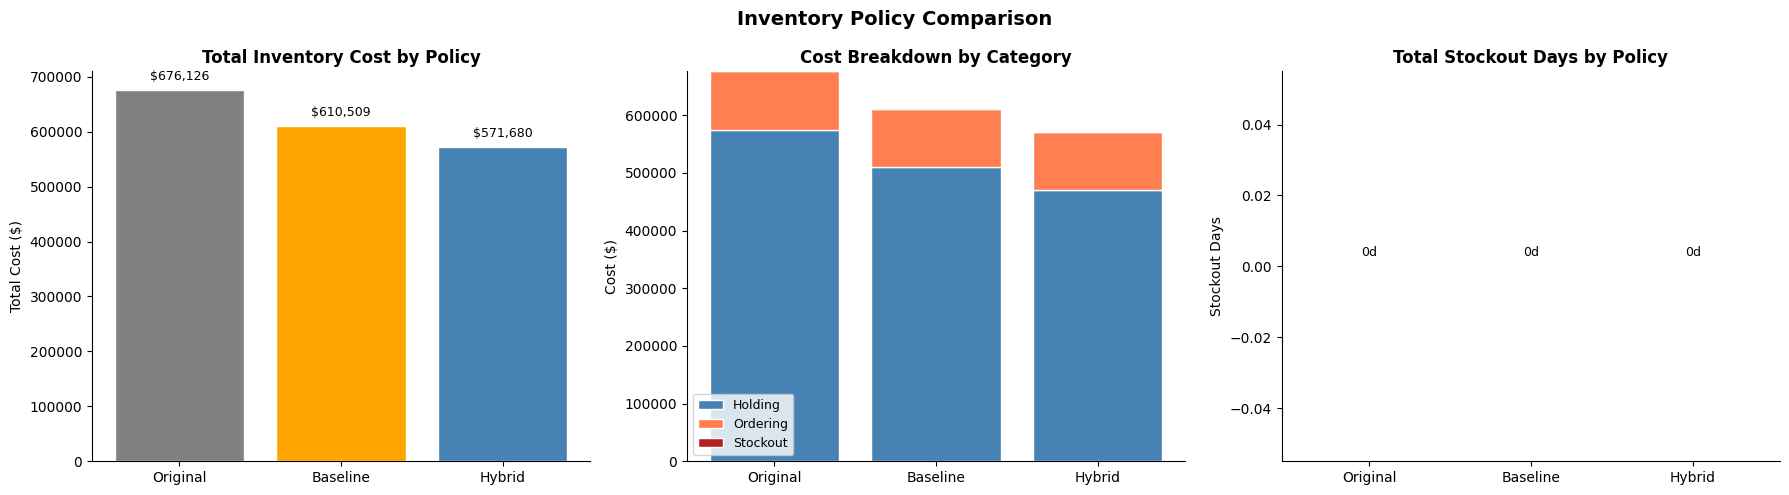

In [10]:
# ── Cost breakdown chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
policies = ['Original', 'Baseline', 'Hybrid']
colors   = ['grey', 'orange', 'steelblue']

# Total cost
total_costs = [policy_summary.loc[p, 'Total_Cost'] for p in policies]
bars = axes[0].bar(policies, total_costs, color=colors, edgecolor='white')
axes[0].bar_label(bars, labels=[f'${v:,.0f}' for v in total_costs], padding=5, fontsize=9)
axes[0].set_title('Total Inventory Cost by Policy')
axes[0].set_ylabel('Total Cost ($)')

# Cost breakdown stacked bar
x       = np.arange(len(policies))
h_costs = [policy_summary.loc[p,'Total_Holding_Cost']  for p in policies]
o_costs = [policy_summary.loc[p,'Total_Ordering_Cost'] for p in policies]
s_costs = [policy_summary.loc[p,'Total_Stockout_Cost'] for p in policies]

axes[1].bar(x, h_costs, label='Holding',  color='steelblue', edgecolor='white')
axes[1].bar(x, o_costs, label='Ordering', color='coral',     edgecolor='white', bottom=h_costs)
axes[1].bar(x, s_costs, label='Stockout', color='firebrick', edgecolor='white',
            bottom=[h+o for h,o in zip(h_costs, o_costs)])
axes[1].set_title('Cost Breakdown by Category')
axes[1].set_xticks(x)
axes[1].set_xticklabels(policies)
axes[1].set_ylabel('Cost ($)')
axes[1].legend(fontsize=9)

# Stockout days
so_days = [policy_summary.loc[p,'Total_Stockout_Days'] for p in policies]
bars2   = axes[2].bar(policies, so_days, color=colors, edgecolor='white')
axes[2].bar_label(bars2, labels=[f'{v:,}d' for v in so_days], padding=5, fontsize=9)
axes[2].set_title('Total Stockout Days by Policy')
axes[2].set_ylabel('Stockout Days')

plt.suptitle('Inventory Policy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📈 Section 8: Inventory Trajectory Visualization

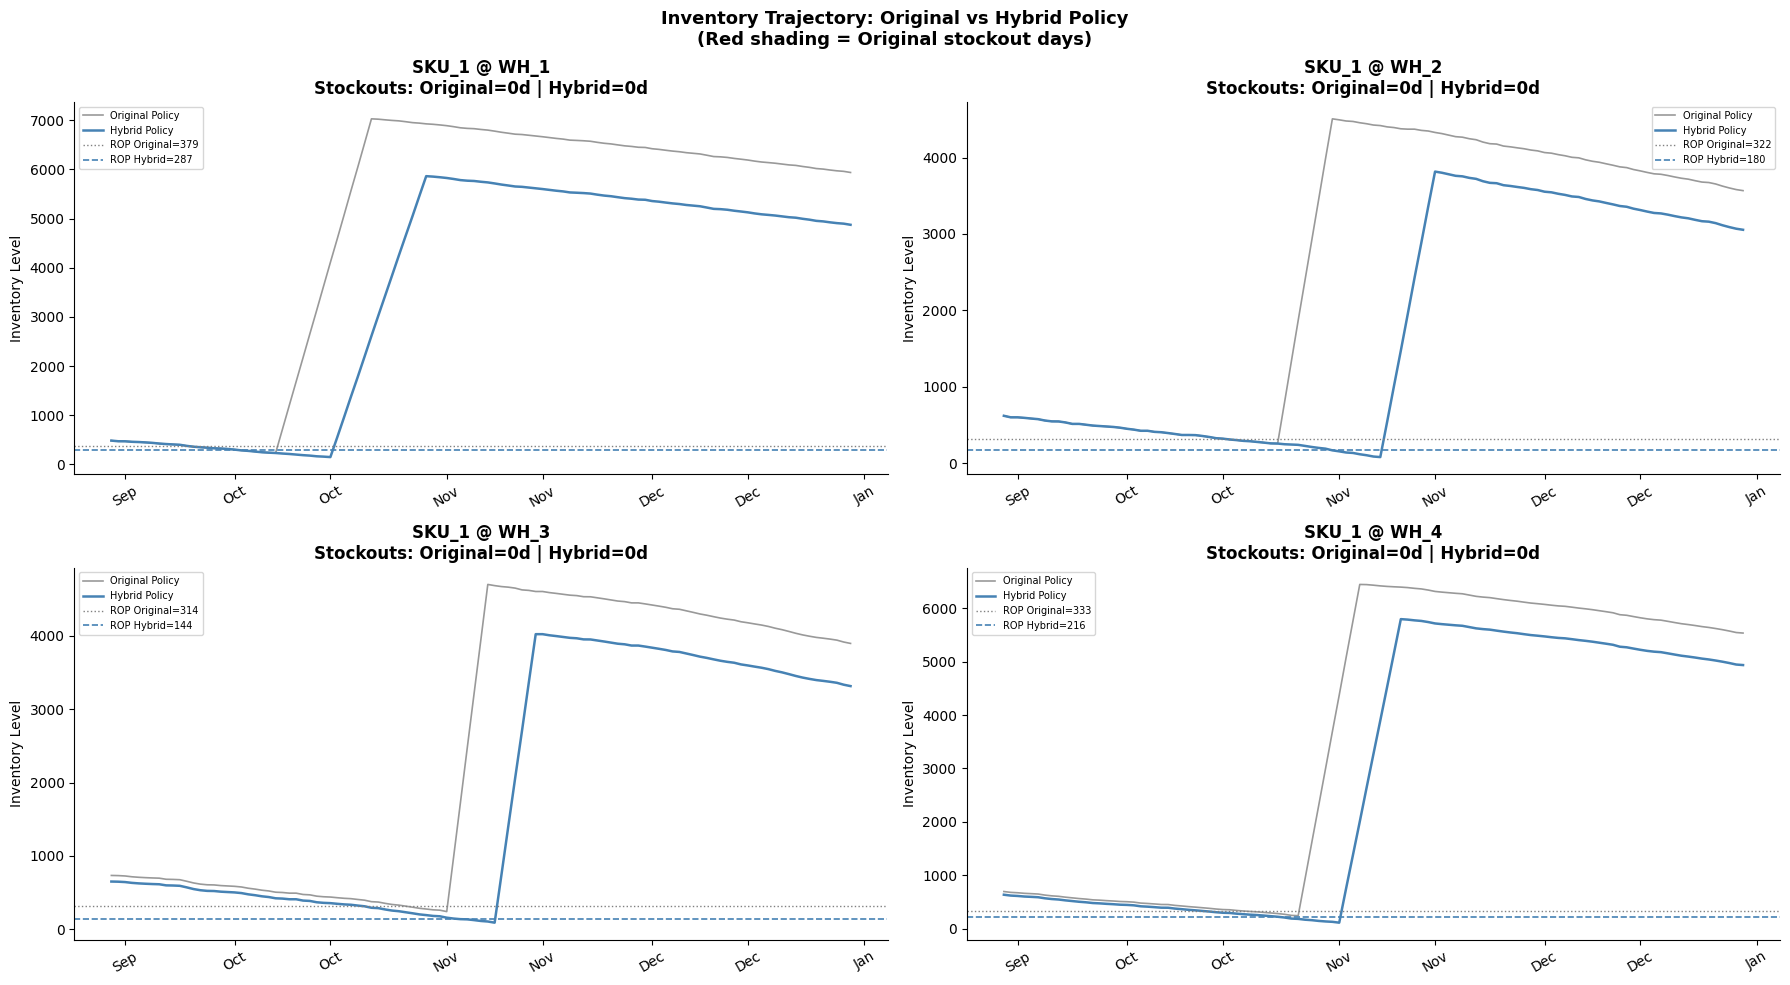

In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 8: INVENTORY TRAJECTORY FOR TOP SKUs
# ─────────────────────────────────────────────────────────────

# Pick 4 SKUs with most stockout events under Original policy
worst_skus = (sim_df_all[sim_df_all['Policy'] == 'Original']
              .nlargest(4, 'Stockout_Days')[GROUP_KEYS].values.tolist())

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, (sku, wh) in enumerate(worst_skus):
    grp = test_raw[(test_raw['SKU_ID'] == sku) & (test_raw['Warehouse_ID'] == wh)]
    p   = sku_policy[(sku_policy['SKU_ID'] == sku) & (sku_policy['Warehouse_ID'] == wh)].iloc[0]

    lead  = p['Avg_Lead_Time']
    init  = grp['Inventory_Level'].iloc[0]

    sim_o = simulate_inventory(grp, p['ROP_Original'], p['EOQ_Original'], lead, init)
    sim_h = simulate_inventory(grp, p['ROP_Hybrid'],   p['EOQ_Hybrid'],   lead, init)

    ax = axes[idx]
    ax.plot(sim_o['Date'], sim_o['Inventory'], color='grey',      linewidth=1.2, label='Original Policy',  alpha=0.8)
    ax.plot(sim_h['Date'], sim_h['Inventory'], color='steelblue', linewidth=1.8, label='Hybrid Policy')
    ax.axhline(p['ROP_Original'], color='grey',      linestyle=':', linewidth=1,   label=f'ROP Original={p["ROP_Original"]:.0f}')
    ax.axhline(p['ROP_Hybrid'],   color='steelblue', linestyle='--',linewidth=1.2, label=f'ROP Hybrid={p["ROP_Hybrid"]:.0f}')

    # Mark stockouts
    so_orig = sim_o[sim_o['Stockout'] == 1]['Date']
    so_hyb  = sim_h[sim_h['Stockout'] == 1]['Date']
    for d in so_orig:
        ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.15, color='red')

    ax.set_title(f'{sku} @ {wh}\nStockouts: Original={len(so_orig)}d | Hybrid={len(so_hyb)}d')
    ax.set_xlabel('')
    ax.set_ylabel('Inventory Level')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Inventory Trajectory: Original vs Hybrid Policy\n(Red shading = Original stockout days)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💼 Section 9: Business Value Summary

In [12]:
# ─────────────────────────────────────────────────────────────
# SECTION 9: BUSINESS VALUE SUMMARY
# ─────────────────────────────────────────────────────────────

print('=' * 60)
print('  💼  BUSINESS VALUE REPORT')
print('  Intelligent Supply Chain Optimization System')
print('=' * 60)

print('\n  📊 FORECAST IMPROVEMENT')
print(f'  Baseline MAPE : — (from Demand_Forecast column)')
print(f'  Hybrid MAPE   : {hybrid_metrics.get("MAPE", 0):.2f}%')
print(f'  Best Strategy : {hybrid_metrics.get("best_strategy", "Hybrid Weighted")}')

print('\n  📦 INVENTORY POLICY')
print(f'  Service Level Target : {SERVICE_LEVEL*100:.0f}%')
print(f'  Safety Stock Method  : Z-score (Z={Z_SCORE})')
print(f'  EOQ Ordering Cost    : ${ORDERING_COST}/order')
print(f'  Holding Cost Rate    : {HOLDING_RATE*100:.0f}% of unit cost/year')

print('\n  💰 COST SAVINGS (Test Period)')
print(f'  Original Policy Total Cost  : ${orig_cost:>12,.2f}')
print(f'  Baseline Policy Total Cost  : ${base_cost:>12,.2f}')
print(f'  Hybrid Policy Total Cost    : ${hyb_cost:>12,.2f}')
print(f'  ─────────────────────────────────────────')
print(f'  Saving vs Original          : ${cost_saving:>12,.2f}  ({pct_saving:+.1f}%)')

print('\n  ⚠️  STOCKOUT REDUCTION')
print(f'  Original Stockout Days  : {int(orig_so):,}')
print(f'  Hybrid   Stockout Days  : {int(hyb_so):,}')
print(f'  Reduction               : {int(orig_so - hyb_so):,} days  ({so_reduction:.1f}%)')

print('\n  📈 INVENTORY EFFICIENCY')
orig_inv = policy_summary.loc['Original', 'Avg_Inventory_Level']
hyb_inv  = policy_summary.loc['Hybrid',   'Avg_Inventory_Level']
print(f'  Avg Inventory (Original) : {orig_inv:.1f} units')
print(f'  Avg Inventory (Hybrid)   : {hyb_inv:.1f} units')
print(f'  Change                   : {hyb_inv - orig_inv:+.1f} units')

print('\n' + '=' * 60)

  💼  BUSINESS VALUE REPORT
  Intelligent Supply Chain Optimization System

  📊 FORECAST IMPROVEMENT
  Baseline MAPE : — (from Demand_Forecast column)
  Hybrid MAPE   : 0.70%
  Best Strategy : XGBoost

  📦 INVENTORY POLICY
  Service Level Target : 95%
  Safety Stock Method  : Z-score (Z=1.645)
  EOQ Ordering Cost    : $50.0/order
  Holding Cost Rate    : 25% of unit cost/year

  💰 COST SAVINGS (Test Period)
  Original Policy Total Cost  : $  676,126.15
  Baseline Policy Total Cost  : $  610,508.87
  Hybrid Policy Total Cost    : $  571,679.75
  ─────────────────────────────────────────
  Saving vs Original          : $  104,446.40  (+15.4%)

  ⚠️  STOCKOUT REDUCTION
  Original Stockout Days  : 0
  Hybrid   Stockout Days  : 0
  Reduction               : 0 days  (0.0%)

  📈 INVENTORY EFFICIENCY
  Avg Inventory (Original) : 2600.7 units
  Avg Inventory (Hybrid)   : 2140.7 units
  Change                   : -460.0 units



---
## 💾 Section 10: Save Results

In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 10: SAVE OUTPUTS
# ─────────────────────────────────────────────────────────────

# Save inventory policy parameters per SKU
save_cols = GROUP_KEYS + [
    'Avg_Daily_Demand', 'Std_Daily_Demand', 'Avg_Lead_Time',
    'Annual_Demand', 'Hybrid_Annual_Demand',
    'Safety_Stock', 'ROP_Original', 'ROP_Baseline', 'ROP_Hybrid',
    'EOQ_Original', 'EOQ_Hybrid',
    'Avg_Unit_Cost', 'Avg_Unit_Price', 'Holding_Cost_Per_Unit'
]
save_cols = [c for c in save_cols if c in sku_policy.columns]
sku_policy[save_cols].to_csv('inventory_policy.csv', index=False)
print('✅ Inventory policy saved: inventory_policy.csv')

# Save simulation results
sim_df_all.to_csv('simulation_results.csv', index=False)
print('✅ Simulation results saved: simulation_results.csv')

# Save policy comparison summary
policy_summary.to_csv('policy_comparison.csv')
print('✅ Policy comparison saved: policy_comparison.csv')

# Save business value JSON
business_value = {
    'cost_saving_vs_original'     : round(cost_saving, 2),
    'pct_cost_saving'             : round(pct_saving, 2),
    'stockout_days_reduction'     : int(orig_so - hyb_so),
    'pct_stockout_reduction'      : round(so_reduction, 2),
    'avg_inventory_change'        : round(hyb_inv - orig_inv, 2),
    'service_level_target'        : SERVICE_LEVEL,
    'hybrid_forecast_mape'        : hybrid_metrics.get('MAPE', 0),
    'best_strategy'               : hybrid_metrics.get('best_strategy', 'Hybrid Weighted')
}
with open('business_value.json', 'w') as f:
    json.dump(business_value, f, indent=2)
print('✅ Business value report saved: business_value.json')

print()
print('   ➡️  Proceed to Notebook 08: Results Dashboard')

✅ Inventory policy saved: inventory_policy.csv
✅ Simulation results saved: simulation_results.csv
✅ Policy comparison saved: policy_comparison.csv
✅ Business value report saved: business_value.json

   ➡️  Proceed to Notebook 08: Results Dashboard


---
## ✅ Notebook 07 Summary

| Component | Detail |
|---|---|
| Safety Stock Formula | Z-score method (Z=1.645 for 95% service level) |
| Reorder Point | ROP = Avg Demand × Lead Time + Safety Stock |
| EOQ Formula | Wilson formula: √(2DS/H) |
| Simulation | (s,Q) policy: order EOQ when inventory ≤ ROP |
| Policies Compared | Original / Baseline Forecast / Hybrid Forecast |
| Cost Model | Holding + Ordering + Stockout costs |

**Outputs:**
- `inventory_policy.csv` — ROP, EOQ, Safety Stock per SKU×Warehouse
- `simulation_results.csv` — per-SKU cost breakdown for all 3 policies
- `policy_comparison.csv` — aggregate summary table
- `business_value.json` — headline KPIs (cost savings, stockout reduction)

**➡️ Proceed to Notebook 08: Results Dashboard**

---
*Intelligent Supply Chain Optimization System | Notebook 07 of 08*